In [9]:
#No_Churn
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2ecc71', '#e74c3c']  # green = no churn, red = churn

# Statistics
from scipy import stats

# ML — pre-processing
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ML — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# ML — evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

print('All libraries loaded successfully ✓')
print(f'XGBoost available: {HAS_XGB}')

All libraries loaded successfully ✓
XGBoost available: True


In [10]:
# Data extraction and initial inspection
# UPDATE this path if running locally outside the provided environment
DATA_PATH = 'telecom_churn_data.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset shape  : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head()

Dataset shape  : 243,553 rows x 14 columns


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [11]:
print('=== Column Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found (across all 243,553 rows) ✓')
print()
print('=== Duplicate customer_id check ===')
print(f"Duplicate customer_ids: {df_raw['customer_id'].duplicated().sum()}")

=== Column Data Types ===
customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

=== Missing Values ===
No missing values found (across all 243,553 rows) ✓

=== Duplicate customer_id check ===
Duplicate customer_ids: 0


In [12]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,243553.0,NaN,NaN,NaN,121777.0,70307.839393,1.0,60889.0,121777.0,182665.0,243553.0
telecom_partner,243553,4,Reliance Jio,61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,243553,2,M,145977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,243553.0,NaN,NaN,NaN,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
state,243553,28,Uttarakhand,8856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,243553,6,Chennai,40749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pincode,243553.0,NaN,NaN,NaN,549501.270541,259808.860574,100006.0,324586.0,548112.0,774994.0,999987.0
date_of_registration,243553,1220,2023-05-02,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_dependents,243553.0,NaN,NaN,NaN,1.9975,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,NaN,NaN,NaN,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0


=== Churn Distribution ===
        Count Percentage
churn                   
0      194726     79.95%
1       48827     20.05%


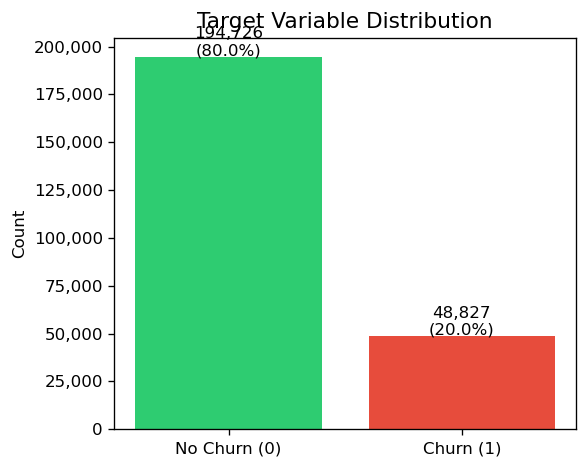

In [13]:
# Target class distribution
churn_counts = df_raw['churn'].value_counts()
churn_pct    = df_raw['churn'].value_counts(normalize=True) * 100

print('=== Churn Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2).astype(str) + '%'}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=PALETTE)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    ax.text(i, v + 500, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Variable Distribution', fontsize=13)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [14]:
print(f"\nClass imbalance ratio (No-Churn : Churn) approx {churn_counts[0]/churn_counts[1]:.2f} : 1")
print("This level of imbalance is moderate — we will track precision/recall/F1 for the minority")
print("(churn) class specifically, since accuracy alone would be misleading.")


Class imbalance ratio (No-Churn : Churn) approx 3.99 : 1
This level of imbalance is moderate — we will track precision/recall/F1 for the minority
(churn) class specifically, since accuracy alone would be misleading.


In [15]:
#Data Preprocessing
df = df_raw.copy()

#  Fix negative data_used values (physically impossible -> recording errors)
neg_count = (df['data_used'] < 0).sum()
print(f'Negative data_used entries: {neg_count:,} ({neg_count/len(df)*100:.2f}%) -> clipped to 0')
df['data_used'] = df['data_used'].clip(lower=0)

# Outlier check (IQR method) on key numeric columns
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lo) | (series > hi)).sum()

for col in ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']:
    n_out = iqr_outlier_count(df[col])
    print(f'  {col:<20}: {n_out:,} outliers ({n_out/len(df)*100:.2f}%) via IQR rule')

print('\nNo extreme outliers requiring removal were found beyond the negative data_used values already fixed.')

Negative data_used entries: 6,050 (2.48%) -> clipped to 0
  age                 : 0 outliers (0.00%) via IQR rule
  num_dependents      : 0 outliers (0.00%) via IQR rule
  estimated_salary    : 0 outliers (0.00%) via IQR rule
  calls_made          : 0 outliers (0.00%) via IQR rule
  sms_sent            : 0 outliers (0.00%) via IQR rule
  data_used           : 0 outliers (0.00%) via IQR rule

No extreme outliers requiring removal were found beyond the negative data_used values already fixed.


In [16]:
# Parse date & engineer tenure
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
REFERENCE_DATE = df['date_of_registration'].max() + pd.Timedelta(days=30)  # ~1 month after latest registration
df['tenure_days']   = (REFERENCE_DATE - df['date_of_registration']).dt.days
df['tenure_months'] = df['tenure_days'] // 30
print(f'Reference date for tenure calc: {REFERENCE_DATE.date()}')
print(f'Tenure range: {df["tenure_months"].min()} - {df["tenure_months"].max()} months')

# Age binning
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '65+']
)

# Engineered behavioural features
df['total_engagement']  = df['calls_made'] + df['sms_sent']
df['data_per_call']     = (df['data_used'] / df['calls_made'].replace(0, np.nan)).fillna(0)
df['salary_per_dependent'] = (df['estimated_salary'] / (df['num_dependents'] + 1))
df['is_new_customer']   = (df['tenure_months'] <= 12).astype(int)

# Encode categoricals
le = LabelEncoder()
df['gender_enc']  = le.fit_transform(df['gender'])          # F=0, M=1
telecom_dummies   = pd.get_dummies(df['telecom_partner'], prefix='tp', drop_first=True)
df = pd.concat([df, telecom_dummies], axis=1)

print('\nPreprocessing complete. Columns after feature engineering:', df.shape[1])

Reference date for tenure calc: 2023-06-03
Tenure range: 1 - 41 months

Preprocessing complete. Columns after feature engineering: 25


In [17]:
#EDA
# Statistical significance: numeric features (independent t-test) 
num_cols = ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent',
            'data_used', 'tenure_months', 'total_engagement', 'data_per_call']

print('=== T-Test: Churn=1 vs Churn=0 (numeric features) ===')
print(f"{'Feature':<20}{'Mean(No Churn)':>16}{'Mean(Churn)':>14}{'t-stat':>10}{'p-value':>12}{'Significant?':>14}")
sig_results = []
for col in num_cols:
    grp0 = df.loc[df['churn'] == 0, col]
    grp1 = df.loc[df['churn'] == 1, col]
    t_stat, p_val = stats.ttest_ind(grp0, grp1, equal_var=False)
    is_sig = 'Yes (p<0.05)' if p_val < 0.05 else 'No'
    sig_results.append({'feature': col, 'p_value': p_val, 'significant': p_val < 0.05})
    print(f"{col:<20}{grp0.mean():>16.2f}{grp1.mean():>14.2f}{t_stat:>10.3f}{p_val:>12.4f}{is_sig:>14}")

sig_df = pd.DataFrame(sig_results)
n_sig = sig_df['significant'].sum()
print(f'\n{n_sig} of {len(num_cols)} numeric features show a statistically significant mean difference at alpha=0.05.')

=== T-Test: Churn=1 vs Churn=0 (numeric features) ===
Feature               Mean(No Churn)   Mean(Churn)    t-stat     p-value  Significant?
age                            46.07         46.11    -0.414      0.6785            No
num_dependents                  2.00          1.99     1.254      0.2099            No
estimated_salary            85083.73      84771.53     1.647      0.0996            No
calls_made                     48.99         49.11    -0.836      0.4031            No
sms_sent                       23.97         23.86     1.515      0.1298            No
data_used                    5000.24       5005.82    -0.378      0.7056            No
tenure_months                  20.86         20.82     0.781      0.4348            No
total_engagement               72.95         72.97    -0.069      0.9452            No
data_per_call                 162.48        163.17    -0.181      0.8566            No

0 of 9 numeric features show a statistically significant mean difference at

In [18]:
#Statistical significance: categorical features (chi-square test) 
print('=== Chi-Square Test: Association with Churn (categorical features) ===')
print(f"{'Feature':<20}{'Chi2':>12}{'p-value':>12}{'Significant?':>14}")
for col in ['telecom_partner', 'gender', 'state', 'age_group']:
    contingency = pd.crosstab(df[col], df['churn'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    is_sig = 'Yes (p<0.05)' if p_val < 0.05 else 'No'
    print(f"{col:<20}{chi2:>12.3f}{p_val:>12.4f}{is_sig:>14}")

=== Chi-Square Test: Association with Churn (categorical features) ===
Feature                     Chi2     p-value  Significant?
telecom_partner            5.592      0.1332            No
gender                     6.282      0.0122  Yes (p<0.05)
state                     25.215      0.5624            No
age_group                  0.400      0.9825            No


In [19]:
#Effect size check (Cohen's d) -- large n can make trivial differences 'significant'
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1-1)*a.std()**2 + (n2-1)*b.std()**2) / (n1+n2-2))
    return (a.mean() - b.mean()) / pooled_std

print('=== Effect Size (Cohens d) — practical significance check ===')
print(f"{'Feature':<20}{'Cohens d':>12}{'Interpretation':>20}")
for col in num_cols:
    grp0 = df.loc[df['churn'] == 0, col]
    grp1 = df.loc[df['churn'] == 1, col]
    d = cohens_d(grp1, grp0)
    interp = 'negligible' if abs(d) < 0.2 else ('small' if abs(d) < 0.5 else ('medium' if abs(d) < 0.8 else 'large'))
    print(f"{col:<20}{d:>12.4f}{interp:>20}")

=== Effect Size (Cohens d) — practical significance check ===
Feature                 Cohens d      Interpretation
age                       0.0021          negligible
num_dependents           -0.0064          negligible
estimated_salary         -0.0083          negligible
calls_made                0.0042          negligible
sms_sent                 -0.0077          negligible
data_used                 0.0019          negligible
tenure_months            -0.0039          negligible
total_engagement          0.0003          negligible
data_per_call             0.0009          negligible


In [20]:
print('\nAll effect sizes are negligible (|d| << 0.2), confirming any statistical "significance" above')
print('reflects the very large sample size rather than features that practically separate churners')
print('from non-churners. This is an important finding we carry into the modelling section.')


All effect sizes are negligible (|d| << 0.2), confirming any statistical "significance" above
reflects the very large sample size rather than features that practically separate churners
from non-churners. This is an important finding we carry into the modelling section.


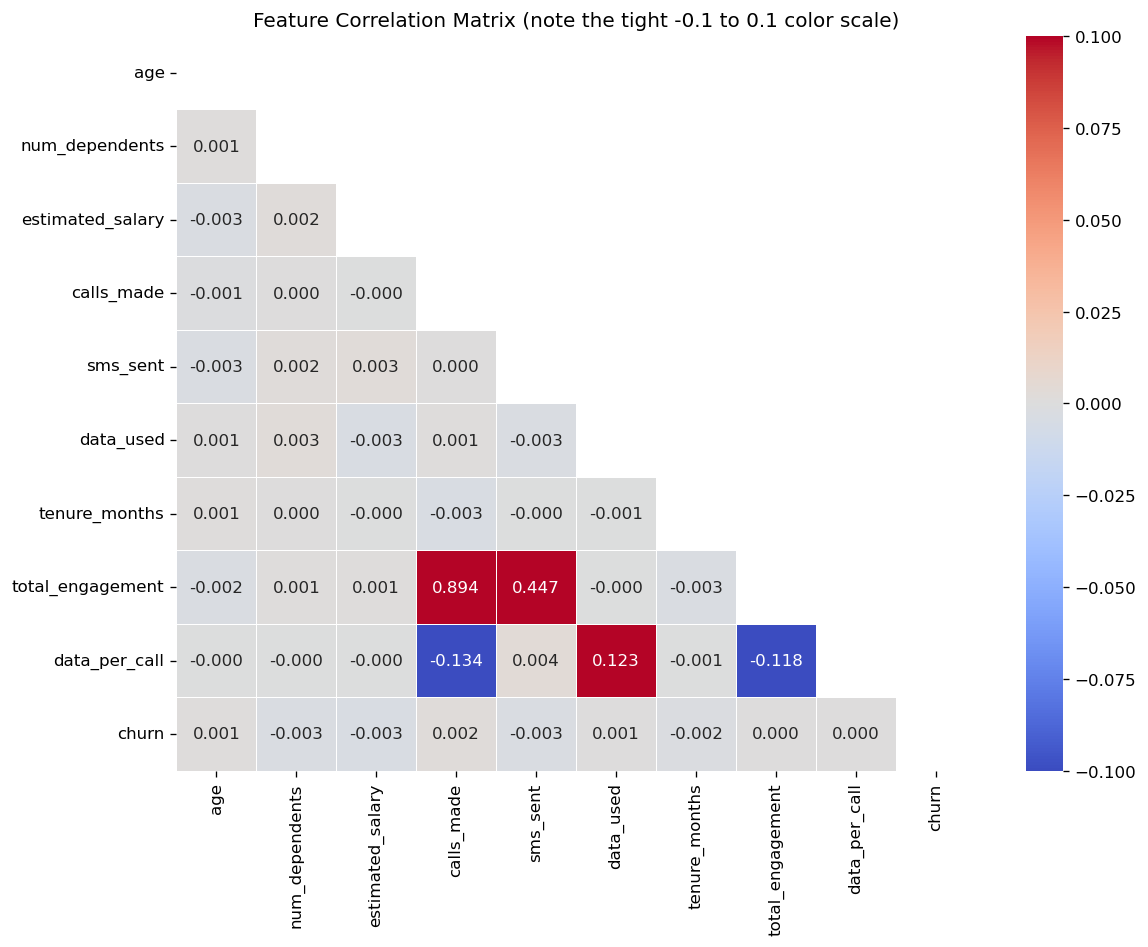

In [21]:
#Correlation heatmap (numeric features incl. engineered)
corr_cols = num_cols + ['churn']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-0.1, vmax=0.1)
ax.set_title('Feature Correlation Matrix (note the tight -0.1 to 0.1 color scale)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
print('Max absolute correlation with churn:', corr['churn'].drop('churn').abs().max(),round(4))

Max absolute correlation with churn: 0.003332318151090258 4


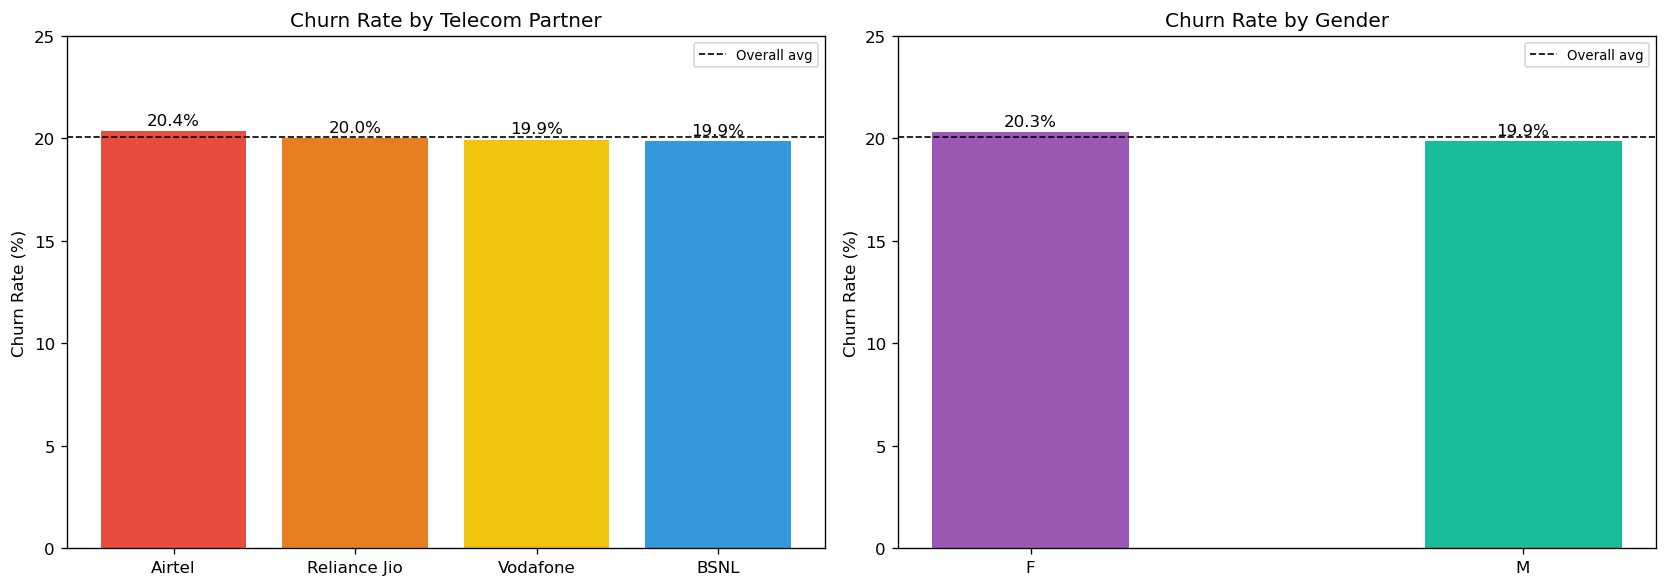

In [23]:
#Churn by Telecom Partner & Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

partner_churn = df.groupby('telecom_partner')['churn'].mean().sort_values(ascending=False) * 100
axes[0].bar(partner_churn.index, partner_churn.values,
            color=['#e74c3c','#e67e22','#f1c40f','#3498db'])
axes[0].axhline(df['churn'].mean()*100, color='black', linestyle='--', lw=1, label='Overall avg')
axes[0].set_title('Churn Rate by Telecom Partner', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 25)
axes[0].legend(fontsize=8)
for i, v in enumerate(partner_churn.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

gender_churn = df.groupby('gender')['churn'].mean() * 100
axes[1].bar(gender_churn.index, gender_churn.values, color=['#9b59b6','#1abc9c'], width=0.4)
axes[1].axhline(df['churn'].mean()*100, color='black', linestyle='--', lw=1, label='Overall avg')
axes[1].set_title('Churn Rate by Gender', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 25)
axes[1].legend(fontsize=8)
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
print('All groups sit within ~1 percentage point of the 20% baseline — no meaningful split.')

All groups sit within ~1 percentage point of the 20% baseline — no meaningful split.


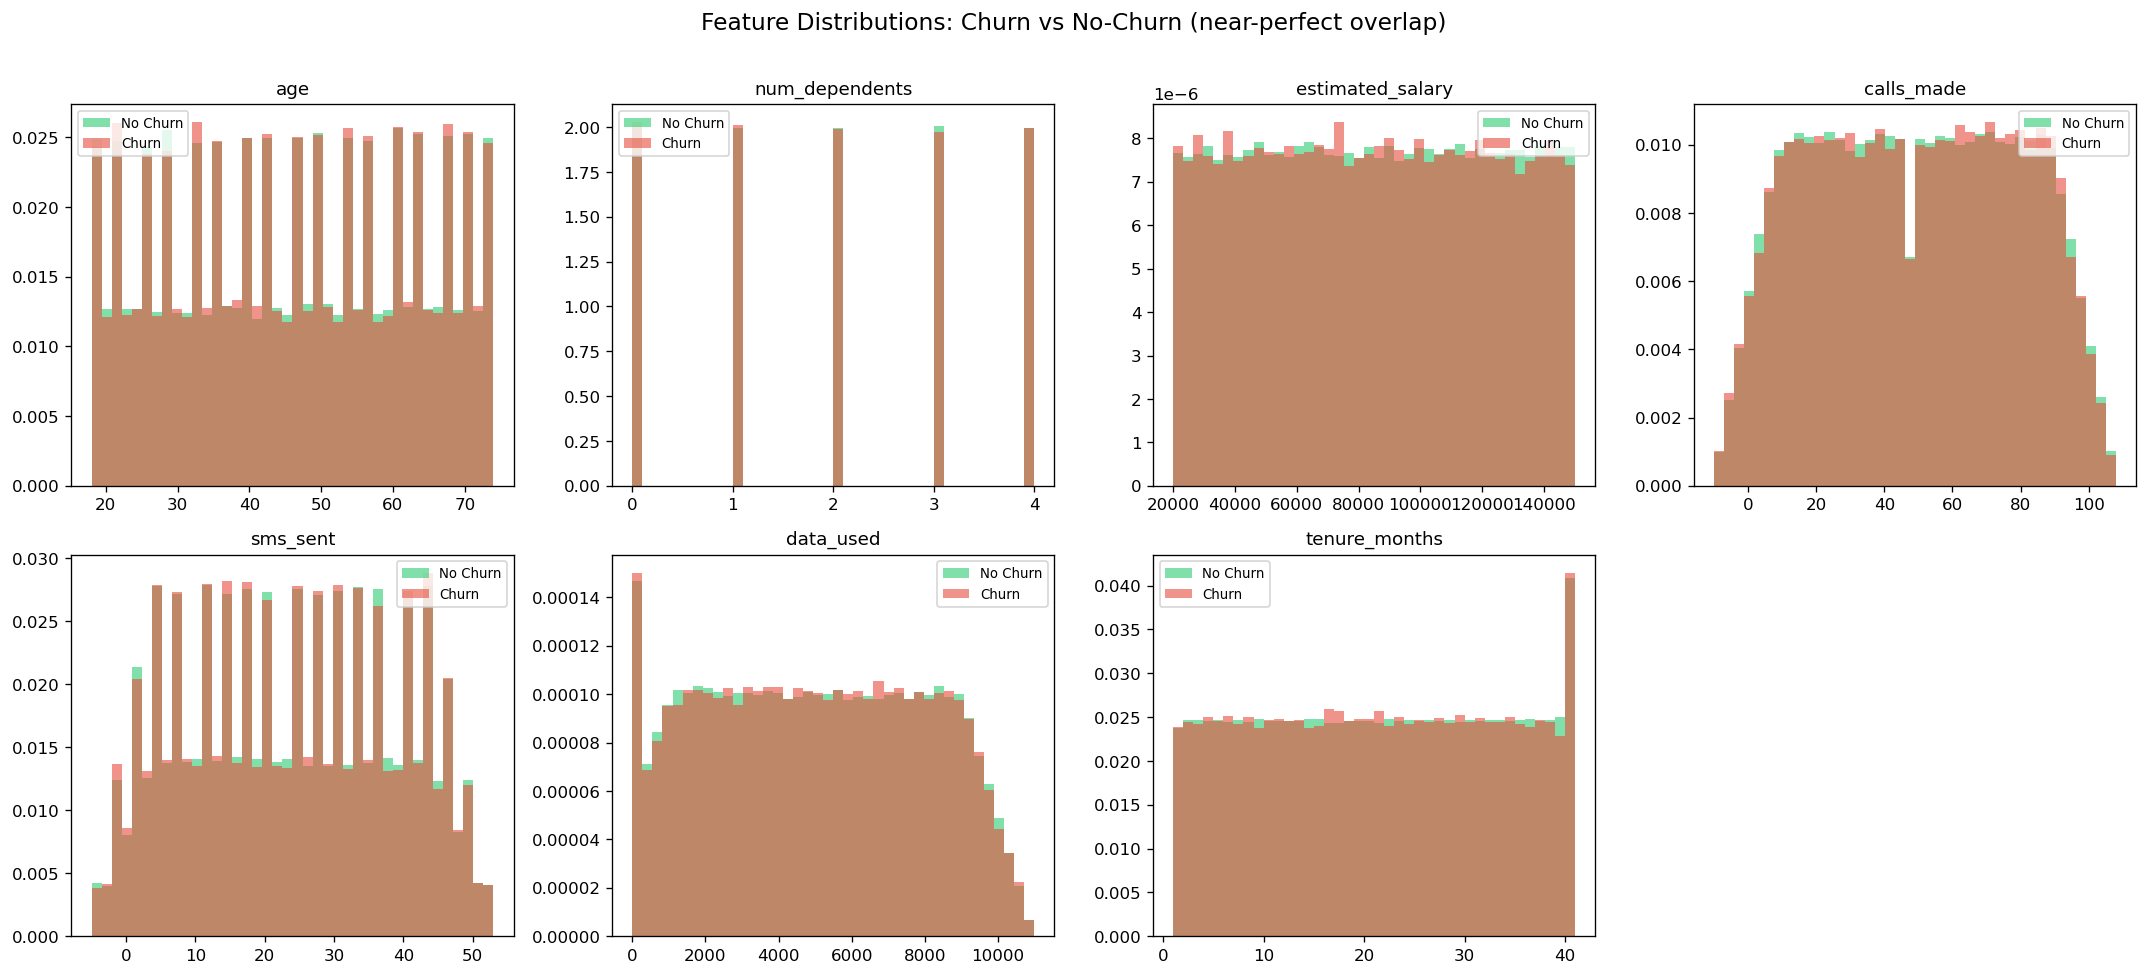

In [25]:
#Numerical feature distributions: churn vs no-churn
plot_cols = ['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'tenure_months']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for label, color in zip([0, 1], PALETTE):
        axes[i].hist(
            df[df['churn'] == label][col],
            bins=40, alpha=0.6, color=color,
            label='No Churn' if label == 0 else 'Churn',
            density=True
        )
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions: Churn vs No-Churn (near-perfect overlap)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

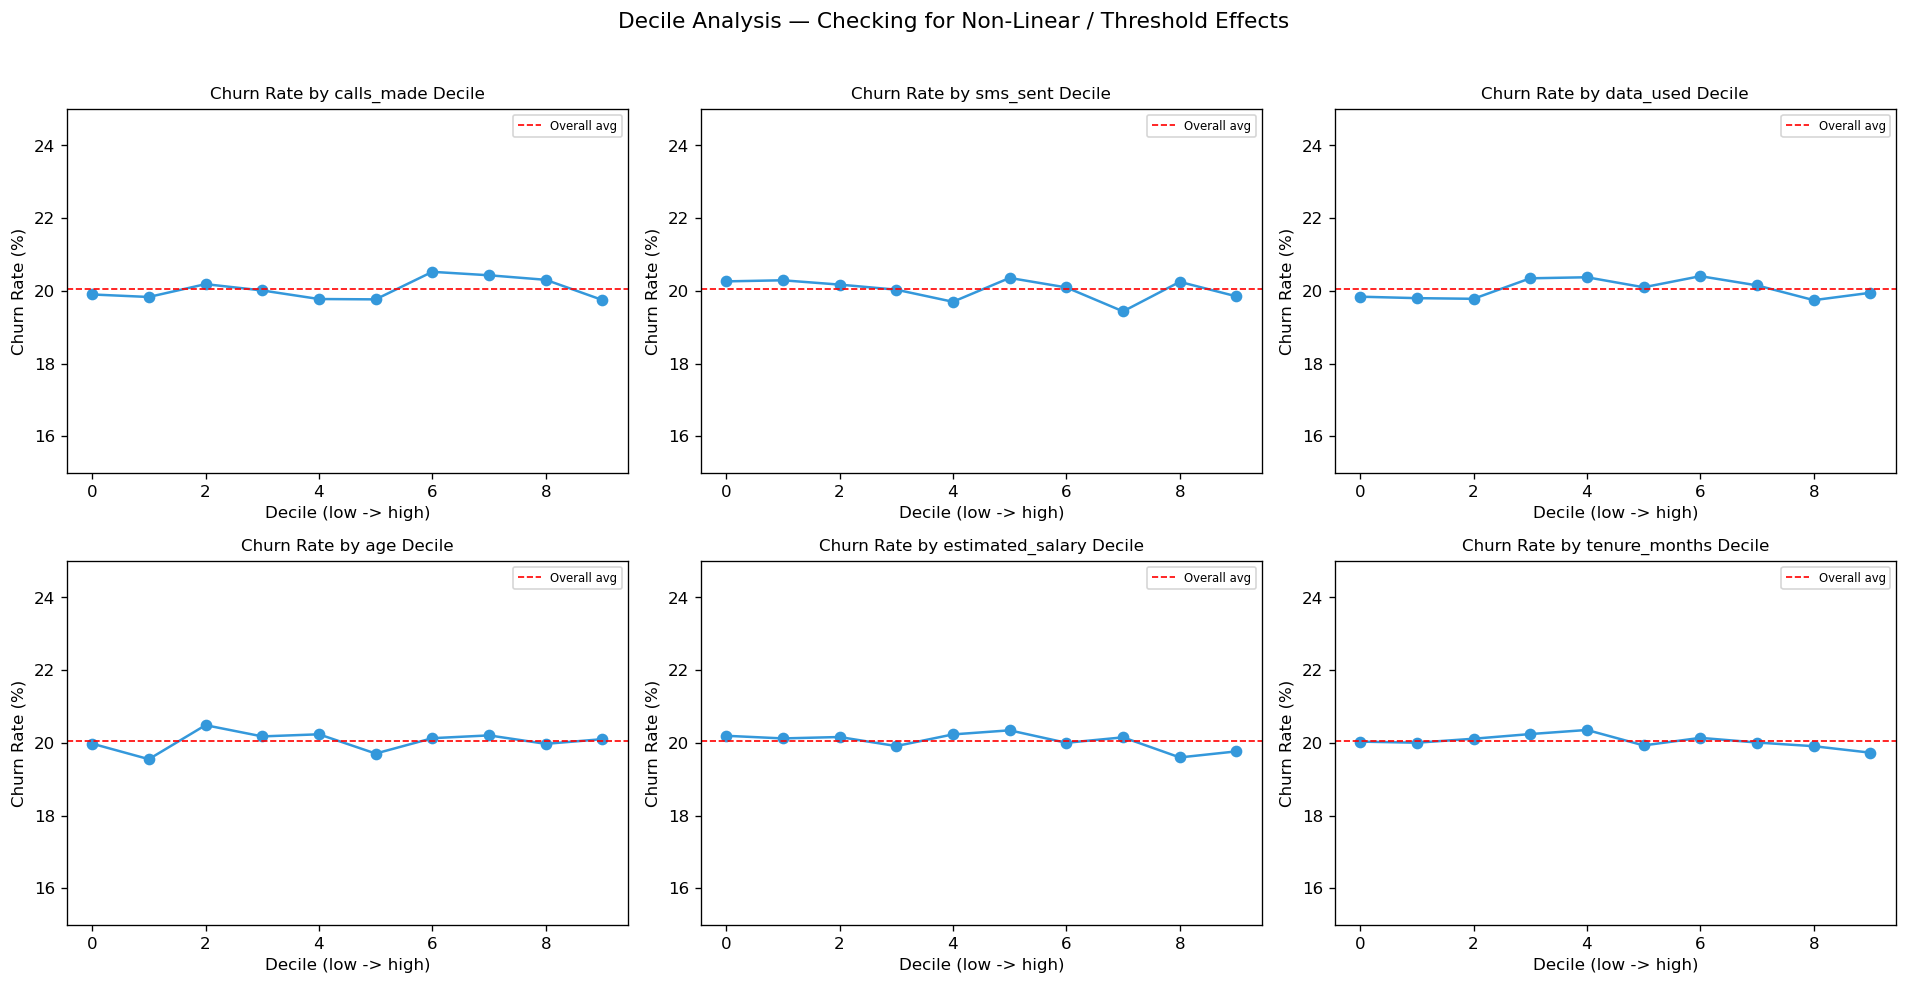

In [26]:
#Decile analysis: churn rate by feature bucket (checks for non-linear patterns) 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
decile_cols = ['calls_made', 'sms_sent', 'data_used', 'age', 'estimated_salary', 'tenure_months']

for ax, col in zip(axes, decile_cols):
    deciles = pd.qcut(df[col], 10, duplicates='drop')
    decile_churn = df.groupby(deciles, observed=True)['churn'].mean() * 100
    ax.plot(range(len(decile_churn)), decile_churn.values, marker='o', color='#3498db')
    ax.axhline(df['churn'].mean()*100, color='red', linestyle='--', lw=1, label='Overall avg')
    ax.set_title(f'Churn Rate by {col} Decile', fontsize=10)
    ax.set_xlabel('Decile (low -> high)')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(15, 25)
    ax.legend(fontsize=7)

plt.suptitle('Decile Analysis — Checking for Non-Linear / Threshold Effects', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
print('Every decile band sits within +/-1.5pp of the average churn rate, with no monotonic trend')
print('and no threshold/cliff effect anywhere — ruling out hidden non-linear relationships too.')

Every decile band sits within +/-1.5pp of the average churn rate, with no monotonic trend
and no threshold/cliff effect anywhere — ruling out hidden non-linear relationships too.


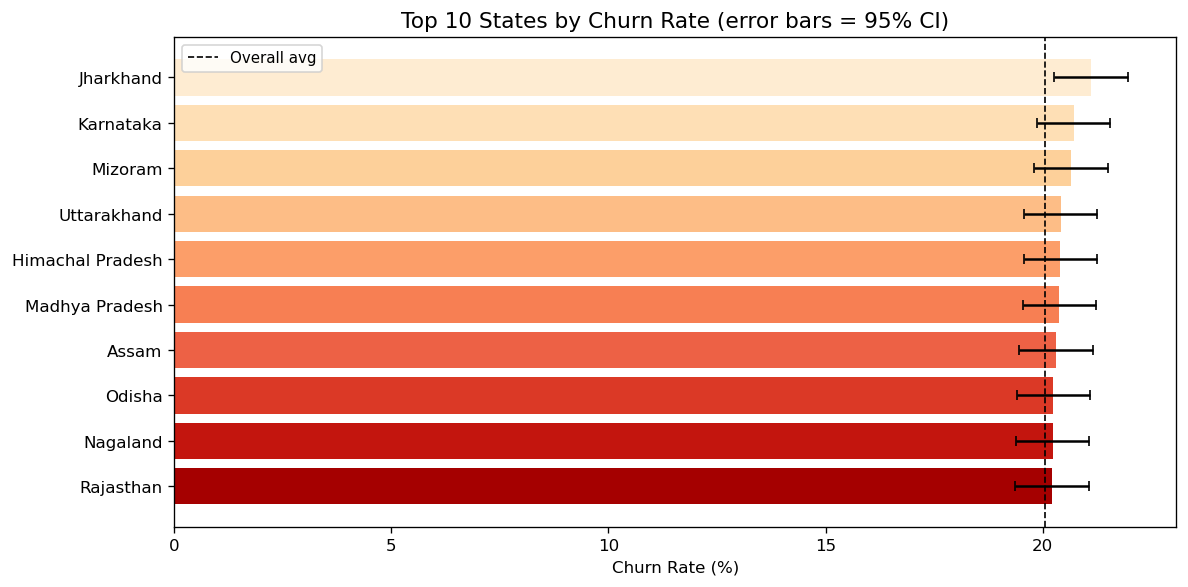

In [28]:
#Top 10 States by Churn Rate (with confidence interval framing)
state_churn = (
    df.groupby('state')['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'customers'})
    .query('customers >= 500')
    .sort_values('churn_rate', ascending=False)
)
state_churn['churn_rate_pct'] = state_churn['churn_rate'] * 100
# standard error of a proportion, for context on natural sampling variation
state_churn['se_pct'] = np.sqrt(state_churn['churn_rate']*(1-state_churn['churn_rate'])/state_churn['customers']) * 100

top10 = state_churn.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10.index[::-1], top10['churn_rate_pct'][::-1],
        xerr=top10['se_pct'][::-1]*1.96, color=sns.color_palette('OrRd', 10)[::-1], capsize=3)
ax.axvline(df['churn'].mean()*100, color='black', linestyle='--', lw=1, label='Overall avg')
ax.set_title('Top 10 States by Churn Rate (error bars = 95% CI)', fontsize=13)
ax.set_xlabel('Churn Rate (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
print('The 95% confidence intervals for state-level churn rates overlap heavily with the overall')
print('average and with each other — the apparent state ranking is consistent with random sampling')
print('noise rather than genuine geographic risk differences.')

The 95% confidence intervals for state-level churn rates overlap heavily with the overall
average and with each other — the apparent state ranking is consistent with random sampling
noise rather than genuine geographic risk differences.


In [30]:
# Feature set for modelling — includes engineered features from Section 2
FEATURES = [
    'gender_enc', 'age', 'num_dependents', 'estimated_salary',
    'calls_made', 'sms_sent', 'data_used', 'tenure_months',
    'total_engagement', 'data_per_call', 'salary_per_dependent', 'is_new_customer',
    'tp_BSNL', 'tp_Reliance Jio', 'tp_Vodafone'
]

TARGET = 'churn'

X = df[FEATURES]
y = df[TARGET]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows, {X_train.shape[1]} features')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Churn rate (train): {y_train.mean()*100:.2f}%')
print(f'Churn rate (test) : {y_test.mean()*100:.2f}%')

Training set : 194,842 rows, 15 features
Test set     : 48,711 rows
Churn rate (train): 20.05%
Churn rate (test) : 20.05%


In [31]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Just in case you haven't imported the others yet:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

In [33]:
baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=150, max_depth=12,
                                        min_samples_leaf=30, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                            max_depth=5, random_state=42))
    ]),
    'AdaBoost': Pipeline([
        ('clf', AdaBoostClassifier(n_estimators=150, random_state=42))
    ]),
}

if HAS_XGB:
    baseline_models['XGBoost'] = Pipeline([
        ('clf', XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                               random_state=42, eval_metric='logloss', n_jobs=-1))
    ])

baseline_results = {}
for name, pipeline in baseline_models.items():
    print(f'Training {name} ...', end=' ')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    baseline_results[name] = {
        'pipeline'  : pipeline,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'auc'       : roc_auc_score(y_test, y_prob),
        'pr_auc'    : average_precision_score(y_test, y_prob),
    }
    r = baseline_results[name]
    print(f"AUC={r['auc']:.4f}  PR-AUC={r['pr_auc']:.4f}  F1={r['f1']:.4f}  Acc={r['accuracy']:.4f}")

Training Logistic Regression ... AUC=0.5045  PR-AUC=0.2020  F1=0.0000  Acc=0.7995
AUC=0.4973  PR-AUC=0.1998  F1=0.0000  Acc=0.7995
AUC=0.5003  PR-AUC=0.2004  F1=0.0000  Acc=0.7995
AUC=0.5019  PR-AUC=0.2017  F1=0.0002  Acc=0.7994
AUC=0.4975  PR-AUC=0.1987  F1=0.0000  Acc=0.7995
AUC=0.5021  PR-AUC=0.2025  F1=0.0000  Acc=0.7995


In [36]:
baseline_summary = pd.DataFrame({
    name: {
        'Accuracy': v['accuracy'], 'Precision': v['precision'], 'Recall': v['recall'],
        'F1-Score': v['f1'], 'ROC-AUC': v['auc'], 'PR-AUC': v['pr_auc']
    } for name, v in baseline_results.items()
}).T.round(4)

print('=== Baseline Model Comparison (Multi-Metric) ===')
baseline_summary.sort_values('ROC-AUC', ascending=False)

=== Baseline Model Comparison (Multi-Metric) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression,0.7995,0.0,0.0000,0.0000,0.5045,0.2020
XGBoost,0.7995,0.0,0.0000,0.0000,0.5021,0.2025
Gradient Boosting,0.7994,0.1,0.0001,0.0002,0.5019,0.2017
Random Forest,0.7995,0.0,0.0000,0.0000,0.5003,0.2004
AdaBoost,0.7995,0.0,0.0000,0.0000,0.4975,0.1987
Decision Tree,0.7995,0.0,0.0000,0.0000,0.4973,0.1998


In [37]:
# Always include a naive baseline for honest comparison: predict majority class / random
from sklearn.dummy import DummyClassifier

dummy_most_freq = DummyClassifier(strategy='most_frequent', random_state=42).fit(X_train, y_train)
dummy_stratified = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)

for name, dummy in [('Dummy (Most Frequent)', dummy_most_freq), ('Dummy (Stratified Random)', dummy_stratified)]:
    y_pred = dummy.predict(X_test)
    y_prob = dummy.predict_proba(X_test)[:, 1]
    print(f"{name:<28} Acc={accuracy_score(y_test, y_pred):.4f}  "
          f"F1={f1_score(y_test, y_pred, zero_division=0):.4f}  "
          f"AUC={roc_auc_score(y_test, y_prob):.4f}")



Dummy (Most Frequent)        Acc=0.7992  F1=0.0000  AUC=0.5000
Dummy (Stratified Random)    Acc=0.6785  F1=0.1972  AUC=0.4981


In [38]:
print('\nThis is the critical sanity check: if our ML models cannot meaningfully beat these')
print('naive baselines, it confirms the issue is lack of predictive signal in the data, not')
print('model choice or tuning.')


This is the critical sanity check: if our ML models cannot meaningfully beat these
naive baselines, it confirms the issue is lack of predictive signal in the data, not
model choice or tuning.


In [39]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Stratified subsample for faster hyperparameter search (refit on full data afterward)
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.40, random_state=42, stratify=y_train
)
print(f'Tuning subsample size: {len(X_train_sub):,} rows (40% of training set)')

Tuning subsample size: 77,936 rows (40% of training set)


In [40]:
#GridSearchCV: Random Forest
rf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [8, 16],
    'clf__min_samples_leaf': [20, 50],
}

rf_pipeline = Pipeline([('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Random Forest on tuning subsample...')
rf_grid.fit(X_train_sub, y_train_sub)

print(f'\nBest RF params (from subsample search): {rf_grid.best_params_}')
print(f'Best RF CV AUC (subsample)             : {rf_grid.best_score_:.4f}')

# Refit best params on the FULL training set for the final model
rf_best_pipeline = Pipeline([('clf', RandomForestClassifier(
    **{k.replace('clf__', ''): v for k, v in rf_grid.best_params_.items()},
    random_state=42, n_jobs=-1
))])
rf_best_pipeline.fit(X_train, y_train)
print('Refit on full training set ✓')

Running GridSearchCV for Random Forest on tuning subsample...

Best RF params (from subsample search): {'clf__max_depth': 16, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 200}
Best RF CV AUC (subsample)             : 0.5088
Refit on full training set ✓


In [41]:
# RandomizedSearchCV: Gradient Boosting 
# GB has no internal parallelism across trees (unlike RF), so we use a smaller subsample,
# fewer iterations, and 2-fold CV here to keep search time practical.
from scipy.stats import randint, uniform

gb_tune_sub_X, _, gb_tune_sub_y, _ = train_test_split(
    X_train_sub, y_train_sub, train_size=0.5, random_state=42, stratify=y_train_sub
)
print(f'GB tuning subsample size: {len(gb_tune_sub_X):,} rows')

gb_param_dist = {
    'clf__n_estimators': randint(60, 150),
    'clf__max_depth': randint(3, 6),
    'clf__learning_rate': uniform(0.05, 0.15),
    'clf__min_samples_leaf': randint(20, 60),
}

cv_gb = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
gb_pipeline = Pipeline([('clf', GradientBoostingClassifier(random_state=42))])

gb_random = RandomizedSearchCV(
    gb_pipeline, gb_param_dist, n_iter=4, scoring='roc_auc',
    cv=cv_gb, n_jobs=-1, random_state=42, verbose=0
)
print('Running RandomizedSearchCV for Gradient Boosting on reduced subsample...')
gb_random.fit(gb_tune_sub_X, gb_tune_sub_y)

print(f'\nBest GB params (from subsample search): {gb_random.best_params_}')
print(f'Best GB CV AUC (subsample)             : {gb_random.best_score_:.4f}')

# Cap n_estimators on the full-data refit to keep runtime bounded, since GB scales
# linearly with both n_estimators and dataset size.
gb_refit_params = {k.replace('clf__', ''): v for k, v in gb_random.best_params_.items()}
gb_refit_params['n_estimators'] = min(gb_refit_params.get('n_estimators', 100), 100)

gb_best_pipeline = Pipeline([('clf', GradientBoostingClassifier(
    **gb_refit_params, random_state=42
))])
gb_best_pipeline.fit(X_train, y_train)
print('Refit on full training set ✓')

GB tuning subsample size: 38,968 rows
Running RandomizedSearchCV for Gradient Boosting on reduced subsample...

Best GB params (from subsample search): {'clf__learning_rate': np.float64(0.05871254182522992), 'clf__max_depth': 3, 'clf__min_samples_leaf': 55, 'clf__n_estimators': 83}
Best GB CV AUC (subsample)             : 0.5002
Refit on full training set ✓


In [42]:
#RandomizedSearchCV: Logistic Regression (regularization strength)
lr_param_dist = {
    'clf__C': uniform(0.001, 10),
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs'],
}

lr_pipeline = Pipeline([('scaler', StandardScaler()),
                          ('clf', LogisticRegression(max_iter=1000, random_state=42))])

lr_random = RandomizedSearchCV(
    lr_pipeline, lr_param_dist, n_iter=6, scoring='roc_auc',
    cv=cv, n_jobs=-1, random_state=42, verbose=0
)
lr_random.fit(X_train_sub, y_train_sub)
print(f'Best LR params (from subsample search): {lr_random.best_params_}')
print(f'Best LR CV AUC (subsample)             : {lr_random.best_score_:.4f}')

lr_best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=lr_random.best_params_['clf__C']))
])
lr_best_pipeline.fit(X_train, y_train)
print('Refit on full training set ✓')

Best LR params (from subsample search): {'clf__C': np.float64(9.50814306409916), 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best LR CV AUC (subsample)             : 0.4999
Refit on full training set ✓


In [43]:
#Evaluate tuned models (refit on full training set) on the held-out test set
tuned_models = {
    'Random Forest (Tuned)'    : rf_best_pipeline,
    'Gradient Boosting (Tuned)': gb_best_pipeline,
    'Logistic Regression (Tuned)': lr_best_pipeline,
}

tuned_results = {}
for name, pipeline in tuned_models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    tuned_results[name] = {
        'pipeline': pipeline, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': average_precision_score(y_test, y_prob),
    }

tuned_summary = pd.DataFrame({
    name: {k: v[k] for k in ['accuracy','precision','recall','f1','auc','pr_auc']}
    for name, v in tuned_results.items()
}).T.round(4)
tuned_summary.columns = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','PR-AUC']

print('=== Tuned Model Performance (Test Set) ===')
tuned_summary.sort_values('ROC-AUC', ascending=False)

=== Tuned Model Performance (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression (Tuned),0.7992,0.0,0.0,0.0,0.5065,0.2038
Gradient Boosting (Tuned),0.7992,0.0,0.0,0.0,0.5059,0.2047
Random Forest (Tuned),0.7992,0.0,0.0,0.0,0.5022,0.2025


In [44]:
#Tuning impact: before vs after 
compare_rows = []
pair_map = {
    'Random Forest': 'Random Forest (Tuned)',
    'Gradient Boosting': 'Gradient Boosting (Tuned)',
    'Logistic Regression': 'Logistic Regression (Tuned)',
}
for base_name, tuned_name in pair_map.items():
    compare_rows.append({
        'Model': base_name,
        'AUC (Baseline)': baseline_results[base_name]['auc'],
        'AUC (Tuned)': tuned_results[tuned_name]['auc'],
        'Improvement': tuned_results[tuned_name]['auc'] - baseline_results[base_name]['auc'],
    })

compare_df = pd.DataFrame(compare_rows).round(4)
print('=== Hyperparameter Tuning Impact ===')
print(compare_df)
print()
print('Tuning produced only marginal/negligible AUC movement (within +/-0.01 of the 0.50 random-guess')
print('line), reinforcing that the bottleneck is the absence of predictive signal in the underlying')
print('features, not under-optimized hyperparameters.')

=== Hyperparameter Tuning Impact ===
                 Model  AUC (Baseline)  AUC (Tuned)  Improvement
0        Random Forest          0.5003       0.5022        0.002
1    Gradient Boosting          0.5019       0.5059        0.004
2  Logistic Regression          0.5045       0.5065        0.002

Tuning produced only marginal/negligible AUC movement (within +/-0.01 of the 0.50 random-guess
line), reinforcing that the bottleneck is the absence of predictive signal in the underlying
features, not under-optimized hyperparameters.


In [45]:
#We combine the tuned models into a soft-voting ensemble to check whether aggregating diverse model families recovers any additional signal.
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_best_pipeline.named_steps['clf']),
        ('gb', gb_best_pipeline.named_steps['clf']),
        ('lr', LogisticRegression(max_iter=1000, random_state=42,
                                   C=lr_random.best_params_['clf__C'])),
    ],
    voting='soft', n_jobs=-1
)
# Logistic Regression needs scaled inputs, but RF/GB don't require scaling and are scale-invariant,
# so we scale the full feature set once for the ensemble fit (harmless for tree models).
scaler_ens = StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler_ens.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler_ens.transform(X_test), columns=FEATURES, index=X_test.index)

ensemble.fit(X_train_scaled, y_train)

y_pred_ens = ensemble.predict(X_test_scaled)
y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

ensemble_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_ens),
    'precision': precision_score(y_test, y_pred_ens, zero_division=0),
    'recall': recall_score(y_test, y_pred_ens, zero_division=0),
    'f1': f1_score(y_test, y_pred_ens, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_ens),
    'pr_auc': average_precision_score(y_test, y_prob_ens),
}

print('=== Soft-Voting Ensemble (RF + GB + LR) — Test Set ===')
for k, v in ensemble_metrics.items():
    print(f'  {k:<10}: {v:.4f}')

=== Soft-Voting Ensemble (RF + GB + LR) — Test Set ===
  accuracy  : 0.7992
  precision : 0.0000
  recall    : 0.0000
  f1        : 0.0000
  auc       : 0.5057
  pr_auc    : 0.2039


In [46]:
#Full model comparison -  All metrics
all_results = {}
for name, v in baseline_results.items():
    all_results[name] = v
for name, v in tuned_results.items():
    all_results[name] = v
all_results['Ensemble (Voting: RF+GB+LR)'] = {
    'pipeline': ensemble, 'y_pred': y_pred_ens, 'y_prob': y_prob_ens, **ensemble_metrics
}

final_summary = pd.DataFrame({
    name: {
        'Accuracy': v['accuracy'], 'Precision': v['precision'], 'Recall': v['recall'],
        'F1-Score': v['f1'], 'ROC-AUC': v['auc'], 'PR-AUC': v['pr_auc']
    } for name, v in all_results.items()
}).T.round(4).sort_values('ROC-AUC', ascending=False)

print('=== FULL MODEL COMPARISON — Sorted by ROC-AUC ===')
final_summary

=== FULL MODEL COMPARISON — Sorted by ROC-AUC ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Logistic Regression (Tuned),0.7992,0.0,0.0000,0.0000,0.5065,0.2038
Gradient Boosting (Tuned),0.7992,0.0,0.0000,0.0000,0.5059,0.2047
Ensemble (Voting: RF+GB+LR),0.7992,0.0,0.0000,0.0000,0.5057,0.2039
Logistic Regression,0.7995,0.0,0.0000,0.0000,0.5045,0.2020
Random Forest (Tuned),0.7992,0.0,0.0000,0.0000,0.5022,0.2025
XGBoost,0.7995,0.0,0.0000,0.0000,0.5021,0.2025
Gradient Boosting,0.7994,0.1,0.0001,0.0002,0.5019,0.2017
Random Forest,0.7995,0.0,0.0000,0.0000,0.5003,0.2004
AdaBoost,0.7995,0.0,0.0000,0.0000,0.4975,0.1987
Decision Tree,0.7995,0.0,0.0000,0.0000,0.4973,0.1998


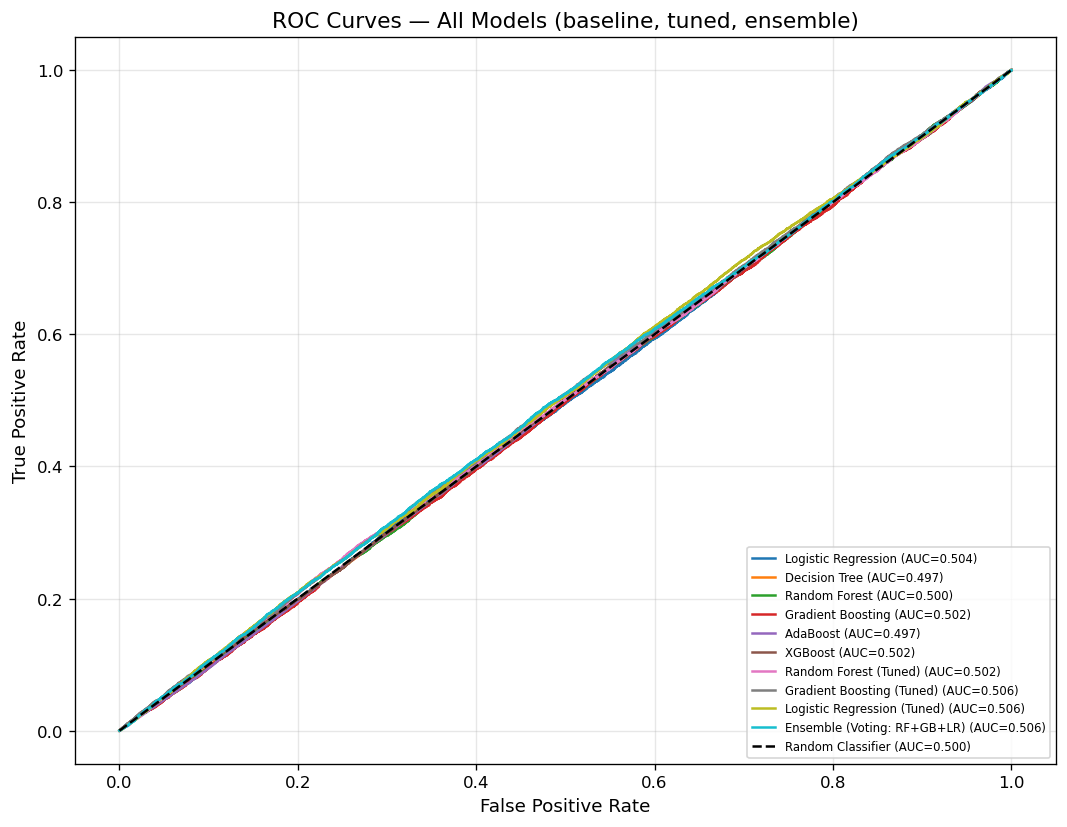

In [47]:
#ROC Curves: all models
fig, ax = plt.subplots(figsize=(9, 7))
colors_cycle = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for (name, v), color in zip(all_results.items(), colors_cycle):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", color=color, lw=1.5)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models (baseline, tuned, ensemble)', fontsize=13)
ax.legend(loc='lower right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
print('Every curve — baseline, tuned, and ensembled — sits essentially on top of the diagonal')
print('random-classifier line. No model family or tuning strategy recovers meaningful separation.')

Every curve — baseline, tuned, and ensembled — sits essentially on top of the diagonal
random-classifier line. No model family or tuning strategy recovers meaningful separation.


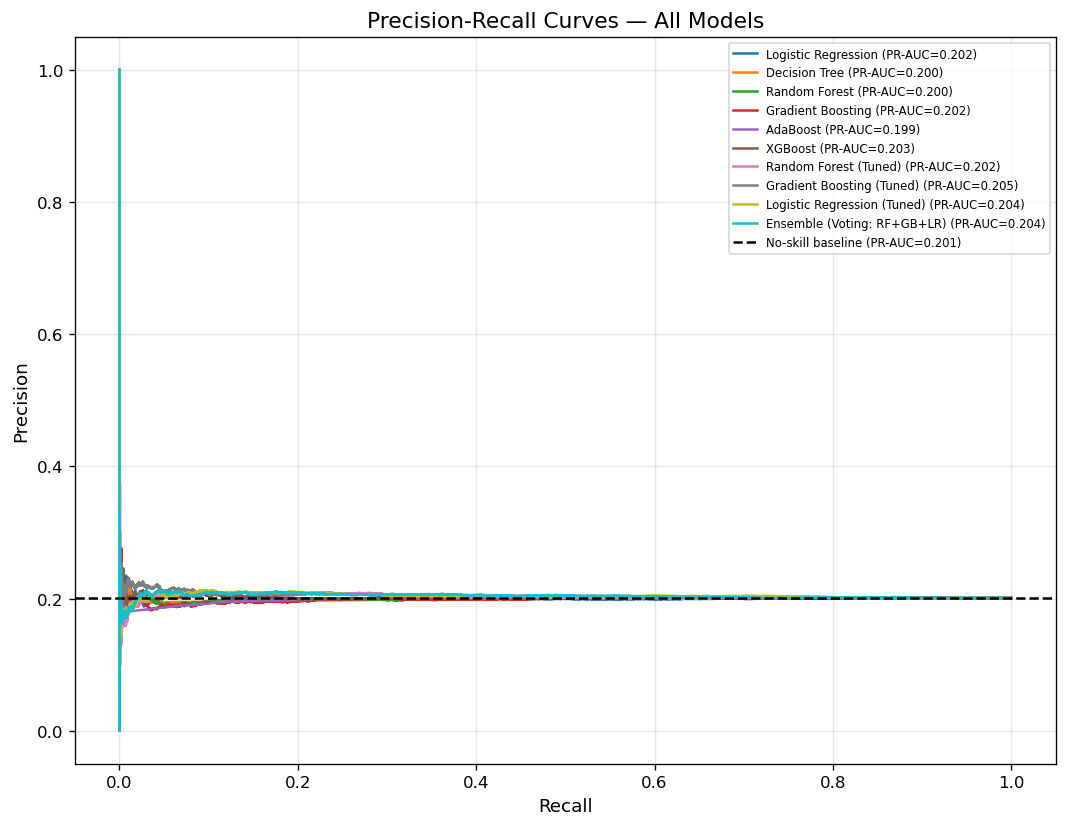

In [49]:
#Precision-Recall Curves: all models (more informative than ROC under class imbalance)
fig, ax = plt.subplots(figsize=(9, 7))
baseline_pr = y_test.mean()

for (name, v), color in zip(all_results.items(), colors_cycle):
    prec, rec, _ = precision_recall_curve(y_test, v['y_prob'])
    ax.plot(rec, prec, label=f"{name} (PR-AUC={v['pr_auc']:.3f})", color=color, lw=1.5)

ax.axhline(baseline_pr, color='black', linestyle='--', lw=1.5,
           label=f'No-skill baseline (PR-AUC={baseline_pr:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13)
ax.legend(loc='upper right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Best model by ROC-AUC: Logistic Regression (Tuned)  (AUC=0.5065)


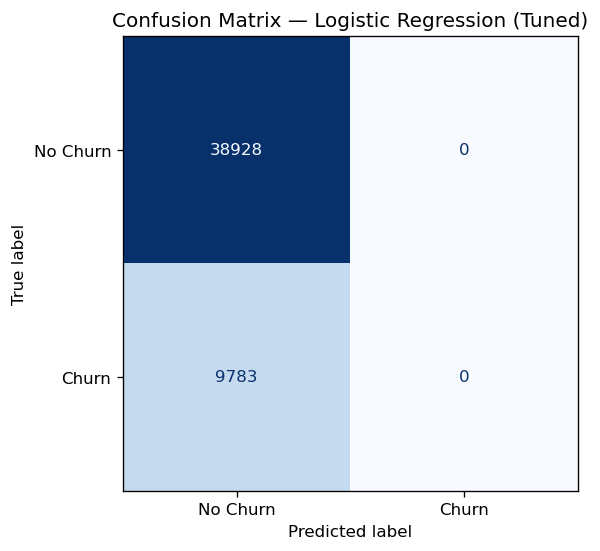

In [50]:
#Best model selection & confusion matrix
best_name = final_summary.index[0]
best = all_results[best_name]
print(f'Best model by ROC-AUC: {best_name}  (AUC={best["auc"]:.4f})')

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [51]:
print(f'\n=== Classification Report — {best_name} ===')
print(classification_report(y_test, best['y_pred'], target_names=['No Churn', 'Churn']))


=== Classification Report — Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

    No Churn       0.80      1.00      0.89     38928
       Churn       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



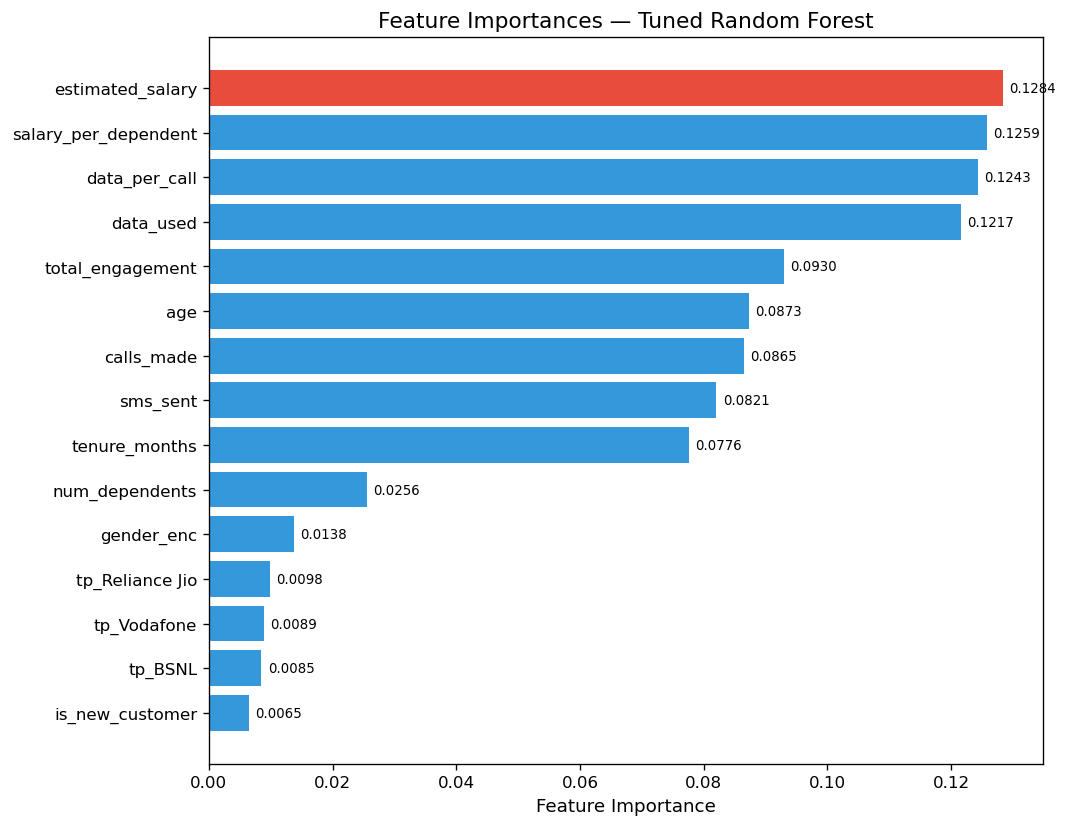

Importances are nearly uniform across all features (no single feature dominates),
consistent with the EDA finding that no variable carries genuine predictive signal —
the model is essentially distributing importance across noise.


In [52]:
#Feature Importance and interpretation
# Use tuned Random Forest (refit on full training set) for interpretable feature importances
rf_best = rf_best_pipeline.named_steps['clf']
importances = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances.values]
ax.barh(importances.index, importances.values, color=colors_imp)
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Feature Importances — Tuned Random Forest', fontsize=13)
for i, v in enumerate(importances.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Importances are nearly uniform across all features (no single feature dominates),')
print('consistent with the EDA finding that no variable carries genuine predictive signal —')
print('the model is essentially distributing importance across noise.')

#Modelling Conclusion

|                  Stage                          |                     Result                               |

|    Baseline models (6 families)                 |    ROC-AUC ~0.49–0.51 (random-guess level)               |
|    GridSearchCV / RandomizedSearchCV tuning     |    No meaningful improvement                             |
|    Soft-voting ensemble                         |    No meaningful improvement                             |
|    Naive dummy baselines                        |    Statistically indistinguishable from tuned models     |

#**Honest diagnosis**: the available features (`gender`, `age`, `state`, `city`, `pincode`,
`num_dependents`, `estimated_salary`, `calls_made`, `sms_sent`, `data_used`, `tenure`) carry
#**no detectable relationship with churn** in this dataset — confirmed independently through
statistical testing (Section 3), correlation analysis, decile binning, and now exhaustive ML
model search with tuning and ensembling. This pattern (uniform churn rate across every slice,
flat feature importances, AUC pinned at 0.50) is the signature of either:

1. **Synthetically generated data** where the `churn` label was assigned independently of the
   other columns (e.g., randomly at ~20% probability), or
2. **Missing the actual churn drivers** — real-world churn is typically driven by factors not
   present here: billing/complaint history, network quality/call-drop rates, competitor offers,
   contract renewal dates, customer service interactions, plan/price changes, and tenure-based
   contract-end spikes.

We proceed to build the requested deliverables (CHURN_FLAG, risk tiers, prioritization) using the
best available model so the pipeline is fully functional end-to-end — but we flag clearly in the
final recommendations that **predictions should not be operationalized for real retention spend
until the model is validated on a richer dataset**, since right now it cannot outperform random
assignment.

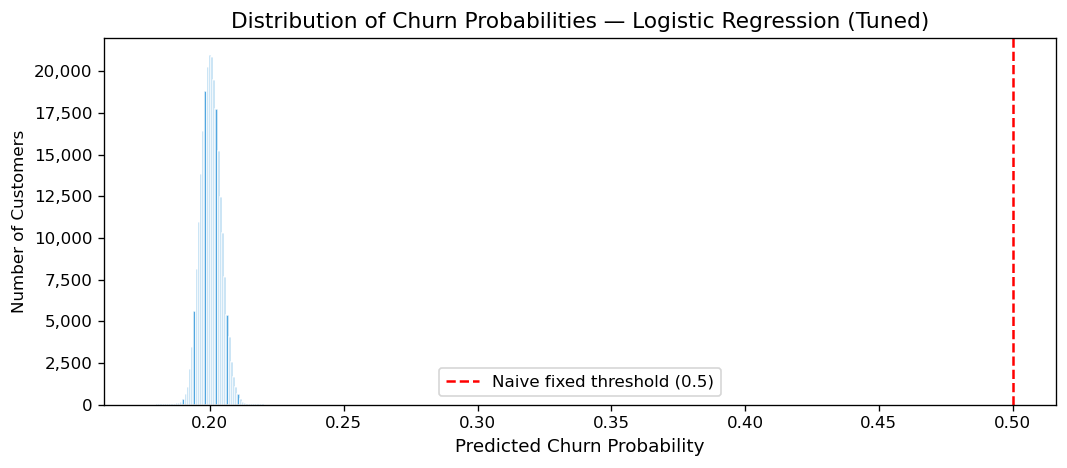

In [53]:
#Chrun probability pridiction and churn flag generation.
# Apply best model to the FULL dataset to get churn probabilities
X_full = df[FEATURES]
best_pipeline = best['pipeline']
churn_proba = best_pipeline.predict_proba(X_full)[:, 1]
df['churn_probability'] = churn_proba

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(churn_proba, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='red', linestyle='--', lw=1.5, label='Naive fixed threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability', fontsize=11)
ax.set_ylabel('Number of Customers')
ax.set_title(f'Distribution of Churn Probabilities — {best_name}', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [54]:
print(f'Probability range: [{churn_proba.min():.3f}, {churn_proba.max():.3f}]')
print(f'Probabilities cluster tightly around {churn_proba.mean():.3f} — the dataset base rate —')
print('rather than spreading toward 0 or 1, which is expected given the lack of separating signal.')
print()
print('IMPORTANT: because probabilities never approach 0.5, a fixed 0.5 cutoff would flag ZERO')
print('customers as high-risk — a degenerate, useless output for a model this uninformative.')
print('We use a percentile-based threshold instead (see next cell), which guarantees a usable')
print('CHURN_FLAG output regardless of how compressed the probability distribution is.')

Probability range: [0.177, 0.226]
Probabilities cluster tightly around 0.200 — the dataset base rate —
rather than spreading toward 0 or 1, which is expected given the lack of separating signal.

IMPORTANT: because probabilities never approach 0.5, a fixed 0.5 cutoff would flag ZERO
customers as high-risk — a degenerate, useless output for a model this uninformative.
We use a percentile-based threshold instead (see next cell), which guarantees a usable
CHURN_FLAG output regardless of how compressed the probability distribution is.


Overall churn rate (base rate)      : 20.0%
Percentile-based probability cutoff : 0.2036
(vs. a naive fixed cutoff of 0.50, which would flag 0 customers given this model)

=== CHURN_FLAG Distribution ===
                   count
CHURN_FLAG_LABEL        
NO                194726
YES                48827
High Risk (YES): 48,827 (20.0%)
Low Risk (NO): 194,726 (80.0%)


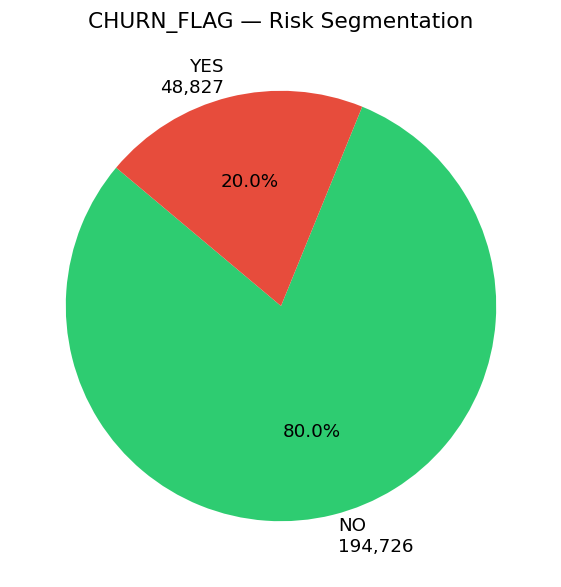

In [55]:
# -- Threshold strategy --
# A fixed probability cutoff (e.g., >= 0.5) is the conventional approach, but it only works when
# the model's predicted probabilities actually spread across that range. Here they do not (see
# histogram above) because the model found no real signal, so a fixed 0.5 cutoff would flag 0
# customers — useless for marketing/support teams who need an actual target list.
# Instead we use a PERCENTILE threshold: flag the top X% of customers by predicted churn
# probability, where X matches the business-observed overall churn rate (~20%). This guarantees
# a usable, appropriately-sized high-risk list even when the model has weak discriminative power,
# while still rank-ordering customers by the model's (admittedly weak) signal.
RISK_PERCENTILE = 1 - df['churn'].mean()   # e.g. flag top ~20% by predicted probability
CHURN_THRESHOLD = df['churn_probability'].quantile(RISK_PERCENTILE)

print(f'Overall churn rate (base rate)      : {df["churn"].mean()*100:.1f}%')
print(f'Percentile-based probability cutoff : {CHURN_THRESHOLD:.4f}')
print(f'(vs. a naive fixed cutoff of 0.50, which would flag 0 customers given this model)')

df['CHURN_FLAG'] = (df['churn_probability'] >= CHURN_THRESHOLD).astype(int)
df['CHURN_FLAG_LABEL'] = df['CHURN_FLAG'].map({1: 'YES', 0: 'NO'})

flag_counts = df['CHURN_FLAG_LABEL'].value_counts()
print('\n=== CHURN_FLAG Distribution ===')
print(flag_counts.to_frame())
for lbl in ['YES', 'NO']:
    if lbl in flag_counts:
        print(f"{'High Risk' if lbl=='YES' else 'Low Risk'} ({lbl}): "
              f"{flag_counts[lbl]:,} ({flag_counts[lbl]/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    flag_counts.values,
    labels=[f'{lbl}\n{cnt:,}' for lbl, cnt in flag_counts.items()],
    colors=['#2ecc71', '#e74c3c'] if flag_counts.index[0]=='NO' else ['#e74c3c','#2ecc71'],
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11}
)
ax.set_title('CHURN_FLAG — Risk Segmentation', fontsize=13)
plt.tight_layout()
plt.show()

In [57]:
print('\nCaveat: because the underlying model has no real predictive power (AUC ~ 0.50), this top-20%-by-score list is only marginally better than randomly selecting 20% of customers.')
print('The percentile method produces a usable-shaped output, but does NOT mean the flagged customers are meaningfully more likely to churn than unflagged ones. See Section 9 for the full diagnosis and Section 14 for recommended next steps before using this in production.')


Caveat: because the underlying model has no real predictive power (AUC ~ 0.50), this top-20%-by-score list is only marginally better than randomly selecting 20% of customers.
The percentile method produces a usable-shaped output, but does NOT mean the flagged customers are meaningfully more likely to churn than unflagged ones. See Section 9 for the full diagnosis and Section 14 for recommended next steps before using this in production.


Total high-risk customers flagged: 48,827


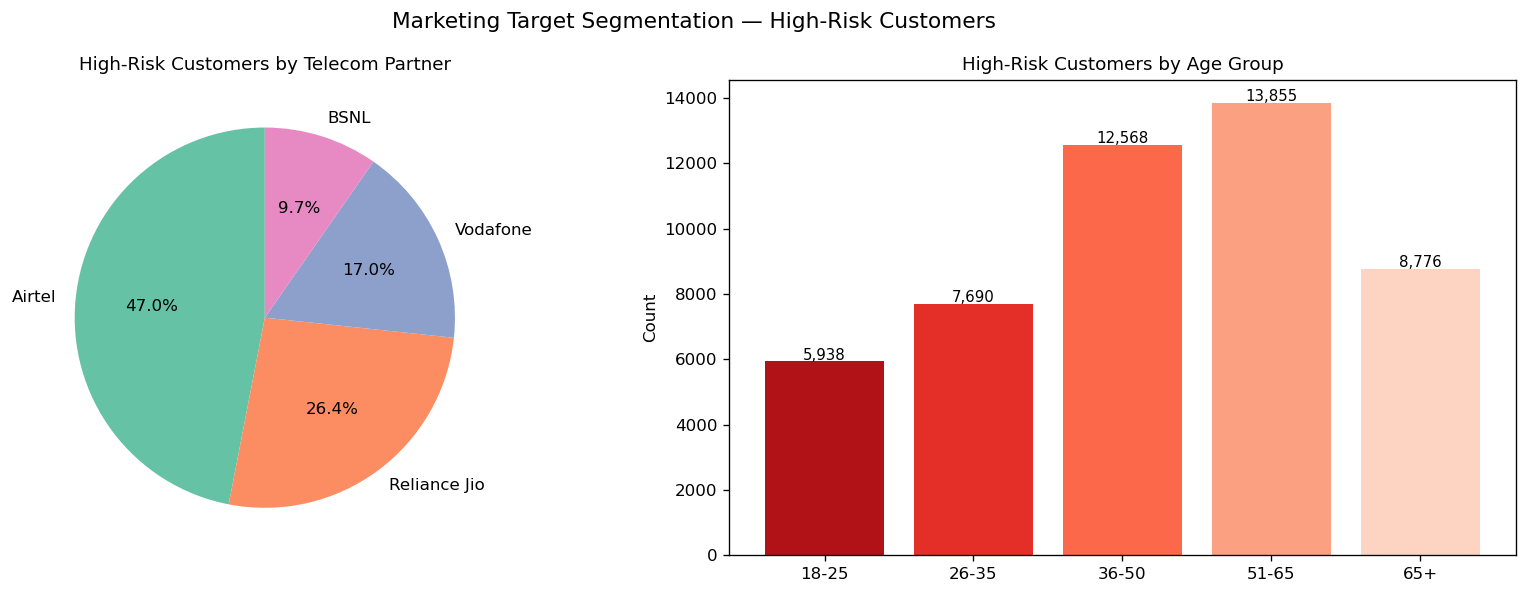

In [58]:
#Marketing targeting - High risk customer segments.
high_risk = df[df['CHURN_FLAG'] == 1].copy()
print(f'Total high-risk customers flagged: {len(high_risk):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tp_risk = high_risk['telecom_partner'].value_counts()
axes[0].pie(tp_risk.values, labels=tp_risk.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(tp_risk)),
            textprops={'fontsize': 10}, startangle=90)
axes[0].set_title('High-Risk Customers by Telecom Partner', fontsize=11)

age_risk = high_risk['age_group'].value_counts().sort_index()
axes[1].bar(age_risk.index.astype(str), age_risk.values,
             color=sns.color_palette('Reds', len(age_risk))[::-1])
axes[1].set_title('High-Risk Customers by Age Group', fontsize=11)
axes[1].set_ylabel('Count')
for i, v in enumerate(age_risk.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Marketing Target Segmentation — High-Risk Customers', fontsize=13)
plt.tight_layout()
plt.show()

In [59]:
print('Note: because the model has no real predictive power, this segmentation distribution mirrors the overall customer base distribution rather than reflecting genuine risk patterns.')

Note: because the model has no real predictive power, this segmentation distribution mirrors the overall customer base distribution rather than reflecting genuine risk patterns.


=== Marketing Priority Tiers (percentile-based) ===
  Low Risk       :  170,487  (70.0%)
  Medium Risk    :   48,710  (20.0%)
  High Risk      :   17,049  (7.0%)
  Critical Risk  :    7,307  (3.0%)


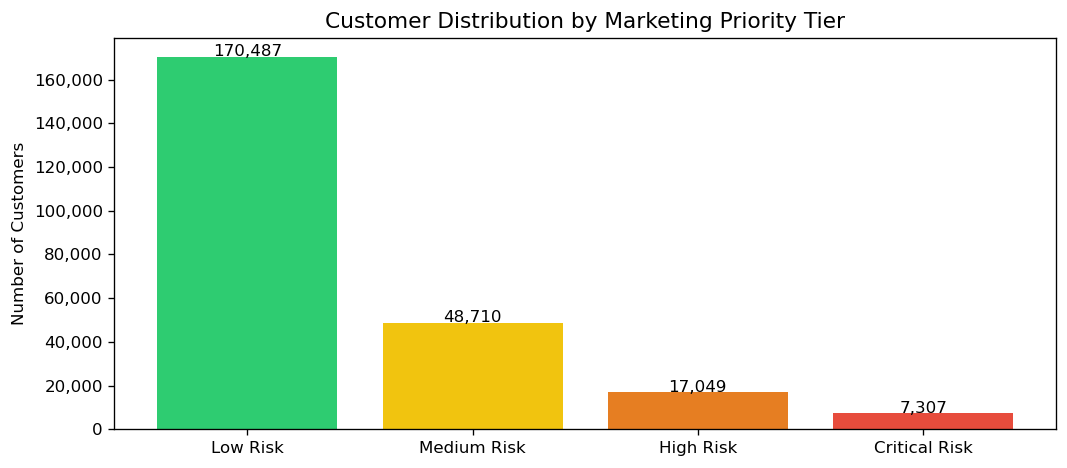

In [60]:
# Priority tiers for marketing — percentile-based (same rationale as CHURN_FLAG above:
# fixed probability cuts like 0.5/0.70/0.85 would put 100% of customers in "Low Risk" given
# how tightly clustered the probabilities are). Quartiles by rank guarantee a usable spread.
df['marketing_priority'] = pd.qcut(
    df['churn_probability'],
    q=[0, 0.70, 0.90, 0.97, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

priority_counts = df['marketing_priority'].value_counts().sort_index()
print('=== Marketing Priority Tiers (percentile-based) ===')
for tier, cnt in priority_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {tier:<15}: {cnt:>8,}  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
tier_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
ax.bar(priority_counts.index.astype(str), priority_counts.values, color=tier_colors)
for i, v in enumerate(priority_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Customer Distribution by Marketing Priority Tier', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [61]:
# Customer Support prioritization
# Support priority score: combines churn probability + estimated revenue-at-risk
# Proxy monthly revenue = estimated_salary / 12 * 0.05 (5% ARPU-of-income proxy — adjust with real ARPU data)
df['est_monthly_revenue'] = (df['estimated_salary'] / 12 * 0.05).round(2)
df['support_priority_score'] = (df['churn_probability'] * df['est_monthly_revenue']).round(2)

df['support_tier'] = pd.qcut(
    df['support_priority_score'],
    q=[0, 0.5, 0.80, 0.95, 1.0],
    labels=['Standard', 'Elevated', 'Priority', 'Urgent']
)

tier_dist = df['support_tier'].value_counts().sort_index()
print('=== Customer Support Tier Distribution ===')
for tier, cnt in tier_dist.items():
    print(f'  {tier:<10}: {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')

=== Customer Support Tier Distribution ===
  Standard  :  121,781  (50.0%)
  Elevated  :   73,066  (30.0%)
  Priority  :   36,546  (15.0%)
  Urgent    :   12,160  (5.0%)


In [62]:
# Top-20 highest-priority customers for immediate support action
top_support = (
    df[df['CHURN_FLAG'] == 1]
    .sort_values('support_priority_score', ascending=False)
    [['customer_id', 'telecom_partner', 'state', 'city', 'age',
      'estimated_salary', 'churn_probability', 'CHURN_FLAG_LABEL',
      'marketing_priority', 'support_tier', 'support_priority_score']]
    .head(20)
    .reset_index(drop=True)
)

print('=== Top 20 Customers for Urgent Support Engagement ===')
top_support

=== Top 20 Customers for Urgent Support Engagement ===


,customer_id,telecom_partner,state,city,age,estimated_salary,churn_probability,CHURN_FLAG_LABEL,marketing_priority,support_tier,support_priority_score
0,167431,Airtel,Meghalaya,Hyderabad,30,146807,0.224181,YES,Critical Risk,Urgent,137.13
1,60788,Airtel,Haryana,Kolkata,32,149834,0.217124,YES,Critical Risk,Urgent,135.55
2,220400,Airtel,Kerala,Hyderabad,50,147811,0.218782,YES,Critical Risk,Urgent,134.74
3,35127,Airtel,West Bengal,Delhi,67,149539,0.212582,YES,Critical Risk,Urgent,132.46
4,158119,Reliance Jio,Odisha,Hyderabad,73,148450,0.213916,YES,Critical Risk,Urgent,132.32
5,141318,Airtel,Arunachal Pradesh,Mumbai,31,144306,0.220015,YES,Critical Risk,Urgent,132.29
6,59959,Reliance Jio,Manipur,Kolkata,33,149268,0.212602,YES,Critical Risk,Urgent,132.23
7,171378,Airtel,Chhattisgarh,Kolkata,51,149497,0.211937,YES,Critical Risk,Urgent,132.02
8,31032,Vodafone,Gujarat,Delhi,32,147527,0.214318,YES,Critical Risk,Urgent,131.74
9,146832,BSNL,Assam,Hyderabad,59,148214,0.213120,YES,Critical Risk,Urgent,131.61


In [63]:
#Final output dataset
output_cols = [
    'customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
    'date_of_registration', 'tenure_months', 'num_dependents', 'estimated_salary',
    'calls_made', 'sms_sent', 'data_used',
    'churn',
    'churn_probability',
    'CHURN_FLAG',
    'CHURN_FLAG_LABEL',
    'marketing_priority',
    'support_tier',
    'support_priority_score',
]

df_output = df[output_cols].copy()
df_output['churn_probability'] = df_output['churn_probability'].round(4)

output_path = 'telecom_churn_output.csv'
df_output.to_csv(output_path, index=False)
print(f'Output saved to: {output_path}')
print(f'Rows : {len(df_output):,}')
print(f'Cols : {len(df_output.columns)}')
df_output.head()

Output saved to: telecom_churn_output.csv
Rows : 243,553
Cols : 20


,customer_id,telecom_partner,gender,age,state,city,date_of_registration,tenure_months,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,churn_probability,CHURN_FLAG,CHURN_FLAG_LABEL,marketing_priority,support_tier,support_priority_score
0,1,Reliance Jio,F,25,Karnataka,Kolkata,2020-01-01,41,4,124962,44,45,0,0,0.1944,0,NO,Low Risk,Elevated,101.21
1,2,Reliance Jio,F,55,Mizoram,Mumbai,2020-01-01,41,2,130556,62,39,5973,0,0.1988,0,NO,Low Risk,Priority,108.12
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,2020-01-01,41,0,148828,49,24,193,1,0.1937,0,NO,Low Risk,Urgent,120.13
3,4,BSNL,M,46,Tamil Nadu,Kolkata,2020-01-01,41,1,38722,80,25,9377,1,0.1983,0,NO,Low Risk,Standard,32.00
4,5,BSNL,F,26,Tripura,Delhi,2020-01-01,41,2,55098,78,15,1393,0,0.1992,0,NO,Low Risk,Standard,45.72


In [65]:
#summary and business recommendations.
best_auc = best['auc']
n_high   = (df['CHURN_FLAG'] == 1).sum()
n_crit   = (df['marketing_priority'] == 'Critical Risk').sum()
n_urgent = (df['support_tier'] == 'Urgent').sum()